# Machine Learning: Exercise session 09

In this exercise session we will focus on support vector machines (SVM), and boosting for the practical parts.

The theoretical exercise deals with kernels used in SVM.

## 1. SVM

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

In [4]:
def plot_dataset(X, y, axes=[-1.5, 2.5, -1, 1.5]):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

def plot_predictions(clf, axes=[-1.5, 2.5, -1, 1.5]):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

* We will use a toy dataset for binary classification in which the data points are shaped as two interleaving half circles. 
Generate the dataset using the `make_moons()` function from `sklearn.datasets` with `n_samples = 100`, `noise = 0.15`, and `random_state = 42`.

In [2]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.15, random_state = 42)

* Plot the data using the function `plot_dataset`.

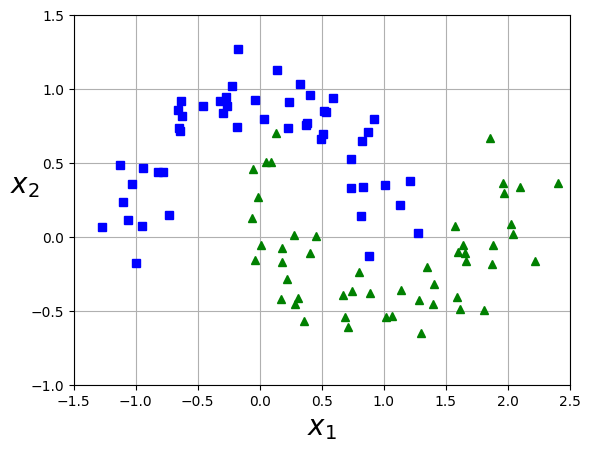

In [5]:
plot_dataset(X, y)

We start by fitting a linear SVM. 

* Create a pipeline to scale the features, and then train a linear SVM model (using the class `LinearSVC` with `C=1` and the hinge loss function).

_Hint_: recall that SVM are sensitive to feature scaling, so it's good pratcice to scale the features before fitting an SVM.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

svm_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C=1, loss='hinge'))
])

svm_lin.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', LinearSVC(C=1, loss='hinge'))])

* Using the functions `plot_dataset` and `plot_predictions` plot the fitted SVM.

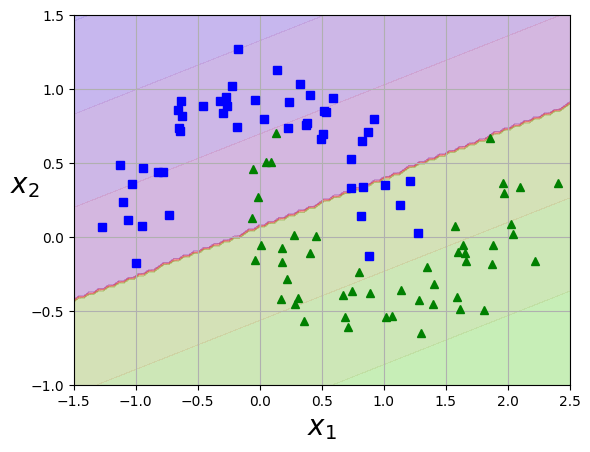

In [8]:
plot_dataset(X, y)
plot_predictions(svm_lin)

Although linear SVM classifiers are efficient and work surprisingly well in many cases, you can see that this dataset is not even close to being linearly separable. One approach to handling nonlinear datasets is to add more features, such as polynomial features; in some cases this can result in a linearly separable dataset.

* To implement this idea using Scikit-Learn, create a `Pipeline` containing a `PolynomialFeatures` with `degree = 3`, followed by a `StandardScaler` and a `LinearSVC` with `C=1` and hinge loss.

In [18]:
from sklearn.preprocessing import PolynomialFeatures

svm_poly = Pipeline([
    ("poly_feat", PolynomialFeatures(degree=3)), # transform observations (rows) explictly
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C=1, loss='hinge'))
])
# (x1, x2) -> (1, x1, x2, x1^2, x1x2, x2^2, x1^3, x1^2x2, x1x2^2, x2^3)
# C has two interpretations:
# i. C is inverse of regularization strength. 
#  High C, low regularization -> flexible model
#  Low C, high regulations -> simple model
# ii. C is inverse of budget.
#  High C, low budget -> we accept only a few missclassfied points
#  Low C, high budget -> we accept many missclassified points

svm_poly.fit(X, y)

Pipeline(steps=[('poly_feat', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm', LinearSVC(C=1, loss='hinge'))])

In [19]:
svm_poly["poly_feat"].n_output_features_

10

* Plot the dataset and the predictions trying different degrees in the `PolymonialFeatures` and different values of the tuning parameter `C`. What are the effects of these tuning parameters?

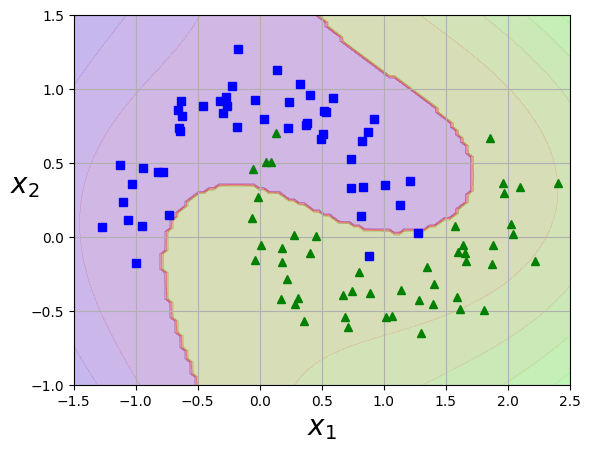

In [20]:
plot_dataset(X, y)
plot_predictions(svm_poly)

* Another useful transformation to apply to the features is the radial basis function. Create a `Pipeline` containing a `RBFSampler` from `sklearn.kernel_approximation`, followed by a `StandardScaler` and a `LinearSVC` with `C=0.1` and hinge loss. 

_Hint_: The `RBFSampler` has a tuning parameter `gamma`. What is its role?

In [37]:
from sklearn.kernel_approximation import RBFSampler

svm_rbf = Pipeline([
    ("rbf_feat", RBFSampler(gamma = 1, n_components=100)), # transform observations (rows) explictly
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C = 1, loss = "hinge", max_iter=int(1e5)))
])

# RBF: gamma controls how "local" the predictions are. You can think of gamma as 
# inverse of k in KNN. 
    
svm_rbf.fit(X, y)

Pipeline(steps=[('rbf_feat', RBFSampler(gamma=1)), ('scaler', StandardScaler()),
                ('svm', LinearSVC(C=1, loss='hinge', max_iter=100000))])

In [38]:
svm_rbf["rbf_feat"].n_components

100

* Plot the dataset and the predictions trying different `gamma` in the `RBFSampler` and different values of the tuning parameter `C`. What are the effects of these tuning parameters?

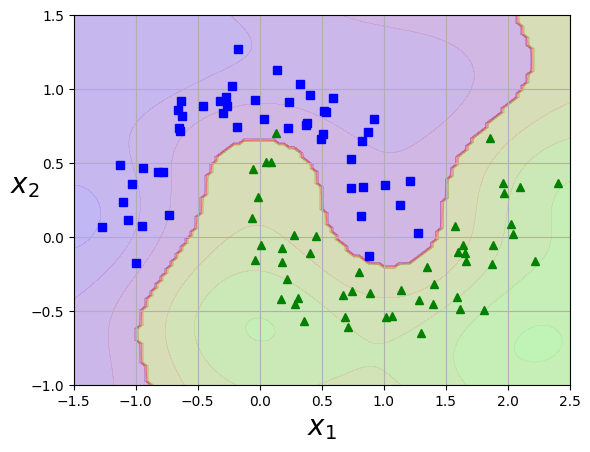

In [39]:
plot_dataset(X, y)
plot_predictions(svm_rbf)

So far, we tried to solve the problem of non linear decision boundary by performing explicit feature transformations (i.e., adding polynomial features or radial basis function). Another way to do this, is by using the _kernel trick_. 
The kernel trick makes it possible to get the same result as if you performed feature transformations, without actually having to add new features.

__Remark__: Using the kernel trick is advisable only for small to medium-sized datasets.
It scales well with the number of features, especially with sparse features (i.e., when each instance has few nonzero features).
When the number of observations gets large (e.g., hundreds of thousands of instances), using the kernel trick is _very_ slow. In such a case, one can still use the approach above for a more reasonable fitting time, i.e., first tranforming features and then applying linear SVM.


* Create a `Pipeline` containing a `StandardScaler` and a `SVC` with `kernel="poly"`, `coef0=1`, `degree=3`, and `C=1`. Fit the pipeline and plot the results as above.

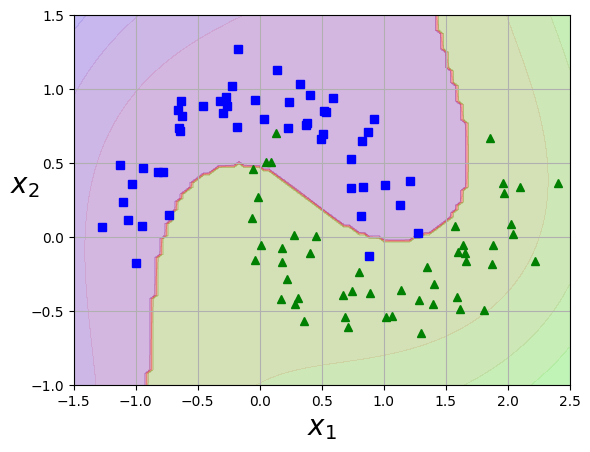

In [40]:
from sklearn.svm import SVC

svm_poly_kern = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='poly', degree=3, coef0=1, C=1)) # transform observations (rows) implicitly
])

svm_poly_kern.fit(X, y)

plot_dataset(X, y)
plot_predictions(svm_poly_kern)

* Create a `Pipeline` containing a `StandardScaler` and a `SVC` with `kernel="rbf"`, `gamma=5`, and `C=1`. Fit the pipeline and plot the results as above.

__Remark__: Notice that the results that you obtain here do not match exactly with `RBFSampler`. In fact, the `RBFSampler` constructs an _approximate_ mapping for the radial basis function kernel.

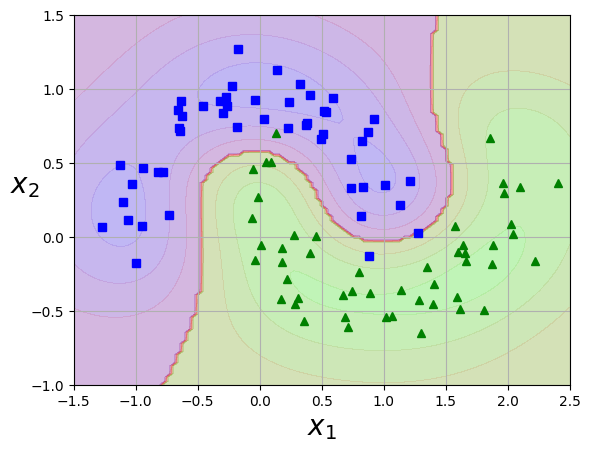

In [47]:
svm_rbf_kern = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='rbf', gamma=1, C=1)) # transform observations (rows) implicitly
])

svm_rbf_kern.fit(X, y)

plot_dataset(X, y)
plot_predictions(svm_rbf_kern)

* For each pipelines created above (except for the simple linear SVM) run a `GridSearchCV` with 10 folds and with the relevant hyperparameters. Rembember to create a common `folds` object.

In [48]:
# Create folds
from sklearn.model_selection import KFold, GridSearchCV

folds = KFold(n_splits=10, random_state=1234, shuffle=True)

In [49]:
# No kernel trick (explicitly transforming observations (rows), i.e., add new features (columns))
# Polynomial

poly_params = {"poly_feat__degree": np.arange(2, 10),
               "svm__C": [1, 10]}

svm_poly = Pipeline([
    ("poly_feat", PolynomialFeatures()),
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(loss = "hinge", max_iter=int(1e5)))
])


svm_poly_cv = GridSearchCV(estimator = svm_poly,
                           param_grid = poly_params,
                           scoring = "accuracy",
                           cv = folds)

svm_poly_cv.fit(X, y)

# RBFSampler
rbf_params = {"rbf_feat__gamma": [0.1, 1, 5, 10, 100],
              "svm__C": [1, 10]}

svm_rbf = Pipeline([
    ("rbf_feat", RBFSampler()),
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(loss = "hinge", max_iter = int(1e5)))
])

svm_rbf_cv = GridSearchCV(estimator = svm_rbf,
                           param_grid = rbf_params,
                           scoring = "accuracy",
                           cv = folds)

svm_rbf_cv.fit(X, y)

# Kernel trick (implicitly transforming obs (rows), i.e., add new features (columns))
# Polynomial
poly_kern_params = {"svm__degree": np.arange(2, 10),
                    "svm__coef0": [1, 5, 10],
                    "svm__C": [1, 10]}

svm_poly_kern = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly"))
])

svm_poly_kern_cv = GridSearchCV(estimator = svm_poly_kern,
                           param_grid = poly_kern_params,
                           scoring = "accuracy",
                           cv = folds)

svm_poly_kern_cv.fit(X, y)


# RBF
rbf_kern_params = {"svm__gamma": [0.1, 1, 5, 10, 100],
                   "svm__C": [1, 10]}

svm_rbf_kern = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

svm_rbf_kern_cv = GridSearchCV(estimator = svm_rbf_kern,
                           param_grid = rbf_kern_params,
                           scoring = "accuracy",
                           cv = folds)

svm_rbf_kern_cv.fit(X, y)

GridSearchCV(cv=KFold(n_splits=10, random_state=1234, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             param_grid={'svm__C': [1, 10], 'svm__gamma': [0.1, 1, 5, 10, 100]},
             scoring='accuracy')

In [50]:
#pd.DataFrame(svm_rbf_kern_cv.cv_results_)
print("Best parameters")
print("Polynomial features:", svm_poly_cv.best_params_)
print("RBF sampler:", svm_rbf_cv.best_params_)
print("Polynomial kernel:", svm_poly_kern_cv.best_params_)
print("RBF kernel:", svm_rbf_kern_cv.best_params_)

Best parameters
Polynomial features: {'poly_feat__degree': 3, 'svm__C': 10}
RBF sampler: {'rbf_feat__gamma': 0.1, 'svm__C': 10}
Polynomial kernel: {'svm__C': 1, 'svm__coef0': 5, 'svm__degree': 4}
RBF kernel: {'svm__C': 10, 'svm__gamma': 1}


* Create a new test dataset and evaluate the best models.

In [51]:
# Generate test data
X_test, y_test = make_moons(n_samples = 1000, noise = 0.15, random_state = 9191)

# Evaluate models
from sklearn.metrics import accuracy_score

print("Test Accuracies")
print("Polynomial features:", accuracy_score(y_test, svm_poly_cv.best_estimator_.predict(X_test)))
print("RBF sampler:", accuracy_score(y_test, svm_rbf_cv.best_estimator_.predict(X_test)))
print("Polynomial kernel:", accuracy_score(y_test, svm_poly_kern_cv.best_estimator_.predict(X_test)))
print("RBF kernel:", accuracy_score(y_test, svm_rbf_kern_cv.best_estimator_.predict(X_test)))

Test Accuracies
Polynomial features: 0.988
RBF sampler: 0.981
Polynomial kernel: 0.99
RBF kernel: 0.987


## 2. Boosting
Boosting refers to any Ensemble method that can combine several weak learners into a strong learner. The general idea of most boosting methods is to train predictors sequentially, each trying to correct its predecessor.


* Let us start by generating some synthetic dataset.

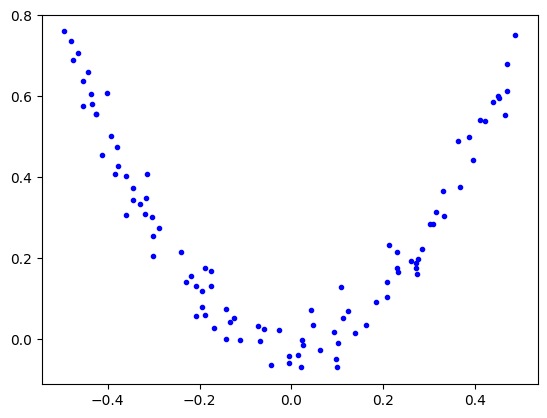

In [52]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100)

# plot data
plt.plot(X[:, 0], y, "b.");

Gradient Boosting works by sequentially adding predictors to an ensemble, each one correcting its predecessor. This method tries to fit the new predictor to the residual errors made by the previous predictor.
Let’s go through a simple regression example, using Decision Trees as the base predictors. This is called Gradient Tree Boosting, or Gradient Boosted Regression Trees (GBRT). 

* First, let’s fit a `DecisionTreeRegressor` with `max_depth=2` on the training set.

In [53]:
from sklearn.tree import DecisionTreeRegressor

tree_reg1 = DecisionTreeRegressor(max_depth=2)
tree_reg1.fit(X, y)

DecisionTreeRegressor(max_depth=2)

In [54]:
tree_reg1.get_n_leaves()

4

* Next, let's fit another `DecisionTreeRegressor` with `max_depth=2` on the _residual_ errors made by the first model. Fill in the `??`.

In [55]:
y2 = y - tree_reg1.predict(X)

tree_reg2 = DecisionTreeRegressor(max_depth=2)
tree_reg2.fit(X, y2)

DecisionTreeRegressor(max_depth=2)

* Now, let's train a third predictor on the residual errors made by the second model. Fill in the `??`.

In [56]:
y3 = y2 - tree_reg2.predict(X)
# i.e. y3 = y - tree_reg1.predict(X) - tree_reg2.predict(X)

tree_reg3 = DecisionTreeRegressor(max_depth=2)
tree_reg3.fit(X, y3)

DecisionTreeRegressor(max_depth=2)

* At this point, we have an ensemble containing three tree predictions. We can make predictions on a new instance simply by adding up the predictions of all the trees. Fill in the ??

In [57]:
np.random.seed(1234)
X_test = np.random.rand(100, 1) - 0.5

y_pred = tree_reg1.predict(X_test) + tree_reg2.predict(X_test) + tree_reg3.predict(X_test)

* Now plot the residual and the esemble predictions using the function `plot_predictions`. Fill in the `??`.

In [58]:
def plot_predictions2(regressors, X, y, axes, style="r-", label=None, data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center", fontsize=16)
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=14)
    plt.ylabel(r"$y$", fontsize=14, rotation=0)

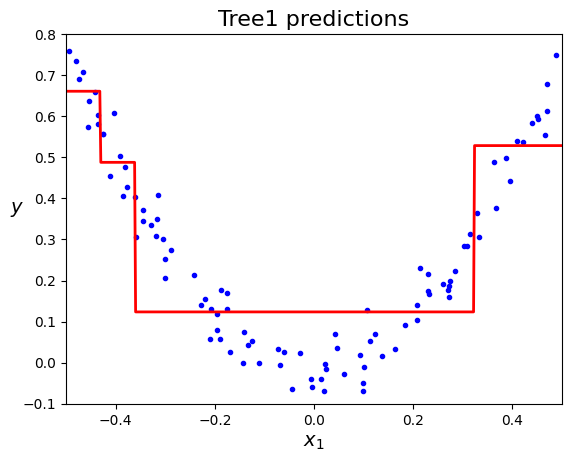

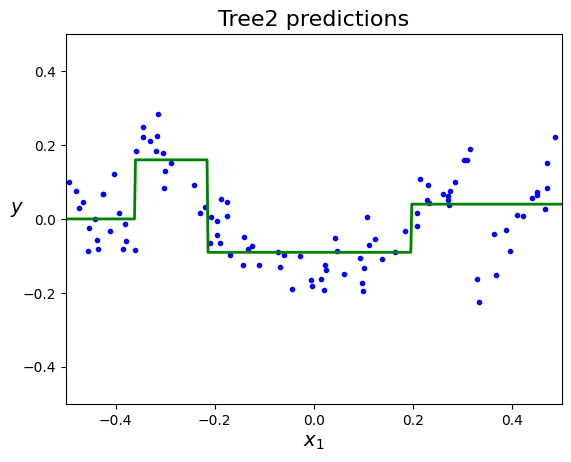

In [59]:
# Plot first predictor
plot_predictions2([tree_reg1], X, y, axes = [-0.5, 0.5, -0.1, 0.8])
plt.title("Tree1 predictions", fontsize=16)
plt.show()

# Plot second predictor alone on the residuals
plot_predictions2([tree_reg2], X, y2, axes = [-0.5, 0.5, -0.5, 0.5], style="g-");
plt.title("Tree2 predictions", fontsize=16)
plt.show()

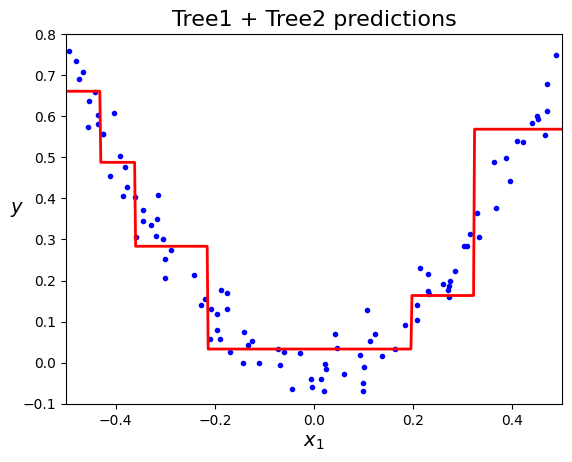

In [60]:
# Plot the first and second predictor together
plot_predictions2([tree_reg1, tree_reg2], X, y, axes = [-0.5, 0.5, -0.1, 0.8])
plt.title("Tree1 + Tree2 predictions", fontsize=16)
plt.show()

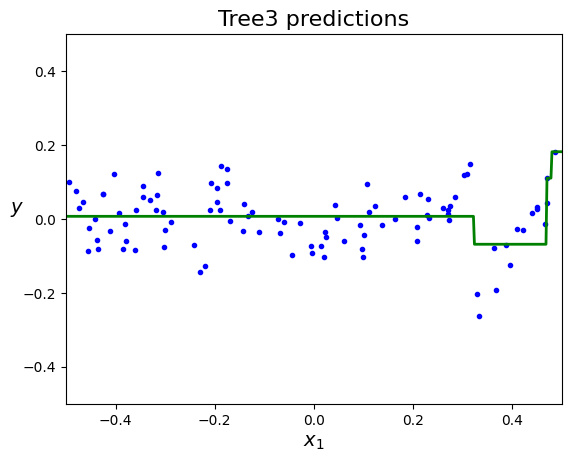

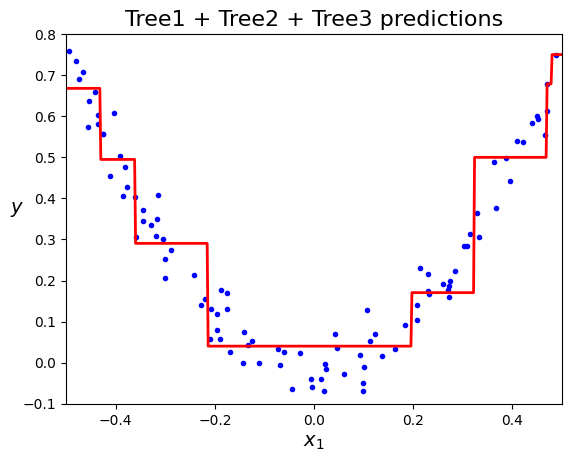

In [61]:
# Plot the third predictor alone on the residuals
plot_predictions2([tree_reg3], X, y3, axes = [-0.5, 0.5, -0.5, 0.5], style="g-");
plt.title("Tree3 predictions", fontsize=16)
plt.show()

# Plot all three prectors together
plot_predictions2([tree_reg1, tree_reg2, tree_reg3], X, y, axes = [-0.5, 0.5, -0.1, 0.8])
plt.title("Tree1 + Tree2 + Tree3 predictions", fontsize=16)
plt.show()

A simpler way to train GBRT ensembles is to use Scikit-Learn’s `GradientBoostingRegressor` class.
Similarly to `RandomForestRegressor`, it has hyperparameters to control the growth of Decision Trees (e.g., `max_depth`, `min_samples_leaf`), as well as hyperparameters to control the ensemble training, such as the number of trees (`n_estimators`) and the shrinkage parameter (`learning_rate`).

* Fit a `GradientBoostingRegressor` with `max_depth=2`, `n_estimators=3`, and `learning_rate=1.0` and plot the predictions.

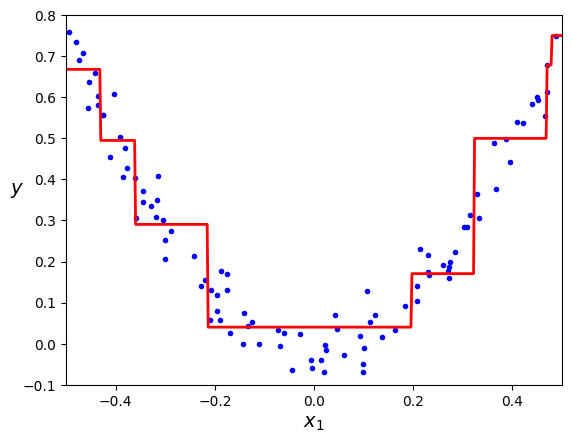

In [62]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators = 3, learning_rate = 1.0, max_depth = 2)
gbr.fit(X, y)

plot_predictions2([gbr], X, y, axes = [-0.5, 0.5, -0.1, 0.8])

The `learning_rate` hyperparameter scales the contribution of each tree. If you set it to a low value, such as 0.01 or 0.001, you will need more trees in the ensemble to fit the training set, but the predictions will usually generalize better. This is a regularization technique called shrinkage.

* Repeat the fitting and plotting above with different values for `n_estimators` and `learning_rate`.

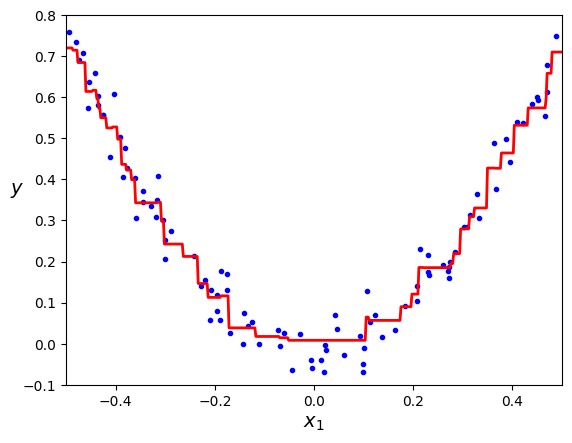

In [66]:
gbr = GradientBoostingRegressor(n_estimators = 500, learning_rate = 0.01, max_depth = 2)
gbr.fit(X, y)

plot_predictions2([gbr], X, y, axes = [-0.5, 0.5, -0.1, 0.8])

* We now apply boosting to the `Heart_ISL.csv` dataset. Recall that this is a classification problem, therefore we need to use `GradientBoostingClassifier`. Fill in the `??`.

In [67]:
heart = pd.read_csv("Heart_ISL.csv",index_col=0).dropna().reset_index(drop=True)
heart = heart.astype({'ChestPain':'category', 'Thal':'category', 'AHD':'category'})
print("Original dataset shape:", heart.shape)
#heart.head()
X = pd.get_dummies(heart.drop("AHD", axis=1), drop_first=True)
y = heart["AHD"]

# Split into train and test dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)

Original dataset shape: (297, 14)


In [68]:
# Fit boosting
from sklearn.ensemble import GradientBoostingClassifier

gbct = GradientBoostingClassifier(max_depth = 2, n_estimators = 1000, learning_rate = 0.01)
gbct.fit(X_train, y_train)
gbct.score(X_test, y_test)

0.85

A better test score could be achieved using a cross-validated grid search to find the best values for the hyperparameters `max_depth`, `learning_rate` and `n_estimators`, as usual.

* Plot the variable importance by filling the `??`.

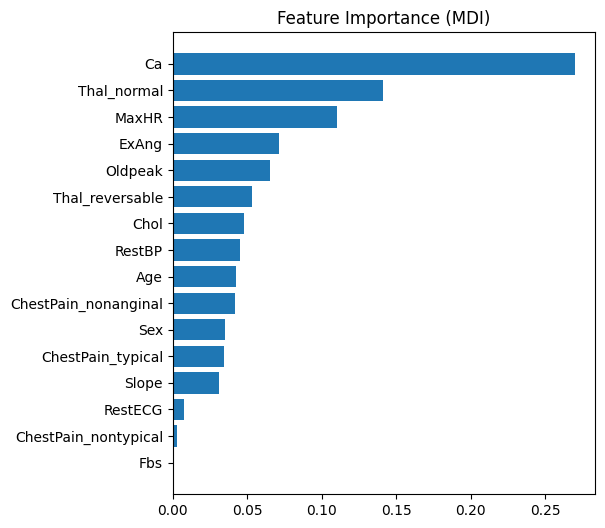

In [69]:
feature_importance = gbct.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, np.array(list(X))[sorted_idx])
plt.title('Feature Importance (MDI)')
plt.show()

## 3. Theoretical Exercise: Kernels

Let $x_1, x_2 \in\mathbb R^3$ be observations in three dimensions (vectors). Consider the kernel function 
$k: \mathbb R^3 \times \mathbb R^3 \to \mathbb R$ defined as $k(x_1, x_2) = (1 + x_1^Tx_2)^2$.

With this exercise, we want to show that any valid kernel _implicitly_ represents
a dot product between two _transformed_ vectors.
In other words, for any
kernel $k$, one can find a transformation of the variables $\phi(x)$
(i.e., a feature transformation) such that $k(x_1, x_2) = \phi(x_1)^T\phi(x_2)$. 

This result helps a lot because one can represent a very high-dimensional feature
transformation without having to compute $\phi(x)$ explicitly (more about this in the
solutions).


1. Find a feature transformation $\phi(x)$, for $x\in\mathbb R^3$, such that 
$k(x_1, x_2) = \phi(x_1)^T \phi(x_2)$.

2. We know that a feature transformation is a function $\phi: \mathbb R^3 \to
\mathcal{X}$ that maps each observation $x\in\mathbb R^3$ to some point $\phi(x)$
in another space $\mathcal{X}$.
What is the dimension of such space $\mathcal{X}$?

### Solutions

1. Consider two observations $x, v\in\mathbb R^3$.
Then we have

  \begin{align*}
  k(x, v) 
  = &\ (1 + x^Tv)^2 = (1 + x_1v_1 + x_2v_2 + x_3v_3)^2\\
  &\ \\
  = &\ (1 + x_1v_1 + x_2v_2 + x_3v_3)(1 + x_1v_1 + x_2v_2 + x_3v_3)\\
  &\ \\
  = &\ 1 + 2 x_1v_1 + 2 x_2v_2 + 2 x_3v_3\\
  &\ + (x_1 v_1) ^ 2 + (x_2 v_2) ^ 2 + (x_3 v_3) ^ 2\\
  &\ + 2 (x_1 x_2)(v_1 v_2) + 2 (x_1 x_3)(v_1 v_3) + 2 (x_2 x_3)(v_2 v_3) \\
  &\ \\
  = &\ [1, \sqrt{2} x_1, \sqrt{2} x_2, \sqrt{2}x_3,
  x_1^2, x_2^2, x_3^2, \sqrt{2}x_1 x_2, \sqrt{2}x_1 x_3, \sqrt{2}x_2 x_3]\\
  &\ \cdot
  [1, \sqrt{2} v_1, \sqrt{2} v_2, \sqrt{2}v_3,
  v_1^2, v_2^2, v_3^2, \sqrt{2}v_1 v_2, \sqrt{2}v_1 v_3, \sqrt{2}v_2 v_3]^T\\
  &\ \\
  = &\ \phi(x)^T\phi(v).\\
  &\ \\
  \end{align*}
  
  
2. We see that the function $\phi$ maps vectors in $\mathbb R^3$ to vectors in $\mathcal{X} = \mathbb R^{10}$. Therefore, the dimension of the transformed space $\mathcal{X}$ is
$\mathrm{dim}(\mathcal{X}) = 10$.